## **Project: Hospital Management Analysis**
Welcome to the start of my end-to-end data analysis project! My goal is to transform raw data into a clear narrative that helps us understand and improve the **financial health** and **operational efficiency** of the hospital.

### **Methodology**
This project will be done in a structured way, following the key stages of a typical data analysis workflow:

**Data Preparation and transformation:** I will start by loading all our datasets, cleaning them, and merging them into a single, comprehensive table. This is the foundation of our analysis.

**Exploratory Data Analysis (EDA):** I will dive into the prepared data to find patterns, relationships, and trends. We'll answer specific business questions, such as which treatments are most profitable.

**Visualization:** I will create visual representations of our findings to make complex data easy to understand for all stakeholders.

**Reporting:** Finally, I will summarize our insights and provide actionable recommendations based on our data-driven conclusions.

### **Data Preparation and Transformation**

#### **Step 1:Uploading and Loading Data**
The first step in this part is to load the five CSV files, This step is critical as it transforms our CSV files into structured DataFrames, which are the foundation of our analysis. Each DataFrame will be a specific component of our hospital's data ecosystem:

**appointments_df:** Captures scheduling details.

**billing_df:** Holds all financial transaction records.

**doctors_df:** Provides information on our medical staff.

**patients_df:** Contains patient demographic information.

**treatments_df:** Details the services provided to patients.

However, I will import all necessary libraries first.

In [1]:
import pandas as pd
print("Pandas library imported successfully.")
import numpy as np
print("Numpy library imported successfully.")
import matplotlib.pyplot as plt
print("Matplotlib library imported successfully.")
import seaborn as sns
print("Seaborn library imported successfully.")

Pandas library imported successfully.
Numpy library imported successfully.
Matplotlib library imported successfully.
Seaborn library imported successfully.


In [2]:
#to upload the dataset
from google.colab import files
uploaded = files.upload()

Saving appointments.csv to appointments.csv
Saving billing.csv to billing.csv
Saving doctors.csv to doctors.csv
Saving patients.csv to patients.csv
Saving treatments.csv to treatments.csv


In [3]:
# Load the five CSV files
appointments_df = pd.read_csv('appointments.csv')
billing_df = pd.read_csv('billing.csv')
doctors_df = pd.read_csv('doctors.csv')
patients_df = pd.read_csv('patients.csv')
treatments_df = pd.read_csv('treatments.csv')

In [4]:
# To preview each of the dataframe
print("\n--- Appointments Data ---")
print(appointments_df.head())
print(appointments_df.info())

print("\n--- Billing Data ---")
print(billing_df.head())
print(billing_df.info())

print("\n--- Doctors Data ---")
print(doctors_df.head())
print(doctors_df.info())

print("\n--- Patients Data ---")
print(patients_df.head())
print(patients_df.info())

print("\n--- Treatments Data ---")
print(treatments_df.head())
print(treatments_df.info())


--- Appointments Data ---
  appointment_id patient_id doctor_id appointment_date appointment_time  \
0           A001       P034      D009       2023-08-09         15:15:00   
1           A002       P032      D004       2023-06-09         14:30:00   
2           A003       P048      D004       2023-06-28          8:00:00   
3           A004       P025      D006       2023-09-01          9:15:00   
4           A005       P040      D003       2023-07-06         12:45:00   

  reason_for_visit     status  
0          Therapy  Scheduled  
1          Therapy    No-show  
2     Consultation  Cancelled  
3     Consultation  Cancelled  
4        Emergency    No-show  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   appointment_id    200 non-null    object
 1   patient_id        200 non-null    object
 2   doctor_id         200 non-null    obj

#### **Step 2: Data Cleaning and Merging**

All datasets have been loaded successfully. As observed in the data overview, several date columns are currently stored as object types. To perform any time-based analysis, such as identifying revenue trends over time, we need to convert these columns to a proper datetime format.

Following this cleaning step, we will merge the four relevant DataFrames "treatments, billing, appointments, and doctors" into a single, unified table. This will create a master_df that links treatments to their costs, billing statuses, and the doctors who performed them. A unified dataset is essential for a comprehensive analysis of our hospital's financial and operational efficiency.



In [5]:
# Convert date columns to datetime
appointments_df['appointment_date'] = pd.to_datetime(appointments_df['appointment_date'])
billing_df['bill_date'] = pd.to_datetime(billing_df['bill_date'])
treatments_df['treatment_date'] = pd.to_datetime(treatments_df['treatment_date'])

In [6]:
# Merging DataFrames
# Step 1: Merge treatments and billing data
treatments_billing_df = pd.merge(treatments_df, billing_df, on='treatment_id', how='left')

# Step 2: Merge the result with appointments data
treatments_billing_appointments_df = pd.merge(treatments_billing_df, appointments_df, on='appointment_id', how='left')

# Step 3: Merge the result with doctors data
hospital_master_df = pd.merge(treatments_billing_appointments_df, doctors_df, on='doctor_id', how='left')

In [7]:
# Displaying the first few rows and information for the master DataFrame
print("Master DataFrame - First 5 Rows:")
print(hospital_master_df.head())
print("Master DataFrame - Info:")
print(hospital_master_df.info())

Master DataFrame - First 5 Rows:
  treatment_id appointment_id treatment_type         description     cost  \
0         T001           A001   Chemotherapy     Basic screening  3941.97   
1         T002           A002            MRI   Advanced protocol  4158.44   
2         T003           A003            MRI  Standard procedure  3731.55   
3         T004           A004            MRI     Basic screening  4799.86   
4         T005           A005            ECG  Standard procedure   582.05   

  treatment_date bill_id patient_id_x  bill_date   amount  ...  \
0     2023-08-09    B001         P034 2023-08-09  3941.97  ...   
1     2023-06-09    B002         P032 2023-06-09  4158.44  ...   
2     2023-06-28    B003         P048 2023-06-28  3731.55  ...   
3     2023-09-01    B004         P025 2023-09-01  4799.86  ...   
4     2023-07-06    B005         P040 2023-07-06   582.05  ...   

  appointment_time reason_for_visit     status first_name last_name  \
0         15:15:00          Therapy 

#### **Step 3: Data Quality Check**

The .info() output showed that there is no missing values, as the Non-Null Count for all columns is 200. This is a great starting point, but it's not enough. there is still need to check for duplicates and potential outliers.

To ensure the integrity of our hospital_master_df. These two key data quality checks are required:

**Duplicate Records:** this is to check if there are any duplicate rows in our dataset. Duplicate records can skew our analysis, leading to incorrect calculations of totals and averages. We'll identify and, if necessary, remove them to ensure each record is unique.

**Outliers:** We will examine the cost and amount columns for any values that are significantly higher or lower than the rest. While we won't necessarily remove outliers, it's important to be aware of them, as they can disproportionately affect our analysis, especially when calculating averages.

In [8]:
# Check for duplicate rows
duplicate_rows = hospital_master_df.duplicated().sum()
print(f"Number of duplicate rows found: {duplicate_rows}")

# Check for outliers in numerical columns
print("\nDescriptive Statistics for Numerical Columns:")
print(hospital_master_df[['cost', 'amount']].describe())

Number of duplicate rows found: 0

Descriptive Statistics for Numerical Columns:
              cost       amount
count   200.000000   200.000000
mean   2756.249250  2756.249250
std    1298.125308  1298.125308
min     534.030000   534.030000
25%    1563.412500  1563.412500
50%    2828.165000  2828.165000
75%    3836.627500  3836.627500
max    4973.630000  4973.630000


The output confirms that our dataset is clean and ready for analysis. The check for duplicate rows came back with a count of 0, which is ideal. The descriptive statistics for cost and amount show that the minimum and maximum values are well within a reasonable range, with no apparent outliers that would skew our initial analysis. This affirms the integrity of the data.

### **Financial Performance Analysis**
**1. Revenue by Treatment**
Now that we have a clean, unified dataset, we can begin to extract meaningful business insights. A key question for any hospital is: Which services are generating the most revenue?

To answer this, we'll perform a simple but powerful analysis. We will group our data by treatment_type and calculate the total revenue generated by each. This will provide a clear picture of our most profitable treatments. The results will be a crucial input for strategic decisions, such as resource allocation or marketing initiatives.


In [9]:
# revenue by treatment analysis
revenue_by_treatment = hospital_master_df.groupby('treatment_type')['amount'].sum().sort_values(ascending=False)

print("Total Revenue by Treatment Type:")
print(revenue_by_treatment)

Total Revenue by Treatment Type:
treatment_type
Chemotherapy     128855.68
MRI              116098.16
X-Ray            110653.67
Physiotherapy     99418.10
ECG               96224.24
Name: amount, dtype: float64


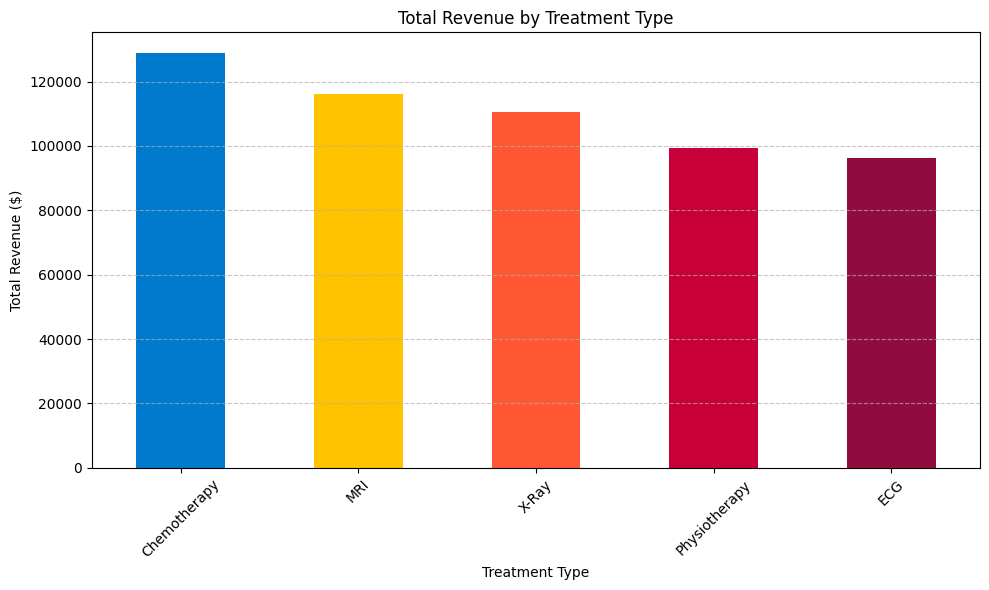

In [10]:
# to visualize revenue by treatment type
plt.figure(figsize=(10, 6))
revenue_by_treatment.plot(kind='bar', color=['#007ACC', '#FFC300', '#FF5733', '#C70039', '#900C3F'])
plt.title('Total Revenue by Treatment Type')
plt.xlabel('Treatment Type')
plt.ylabel('Total Revenue ($)')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

The output provides a clear, data-driven answer to our first business question. We can see that Chemotherapy is the highest-grossing treatment type, followed by MRI, and then X-Ray. This information is a critical first step in understanding our revenue streams.

**2. Analyzing Payment Status and Method**

Now that we understand our revenue drivers, the next logical step is to analyze the financial health of those payments. A crucial question to answer is: What is the breakdown of our payment statuses (Paid, Pending, Failed), and how does this relate to the payment methods used?

Answering this question will help us identify potential issues in our billing process and understand which payment methods are most reliable. This analysis can lead to actionable recommendations for improving cash flow and reducing outstanding payments.

In [11]:
# payment summary
payment_summary = hospital_master_df.groupby(['payment_status', 'payment_method']).agg(
    total_transactions=('bill_id', 'count'),
    total_amount=('amount', 'sum')
).sort_values(by='total_amount', ascending=False)

print("Payment Status and Method Summary:")
print(payment_summary)

Payment Status and Method Summary:
                               total_transactions  total_amount
payment_status payment_method                                  
Pending        Credit Card                     28      76039.45
Failed         Cash                            23      65649.75
               Credit Card                     23      64965.87
               Insurance                       21      62597.32
Paid           Credit Card                     24      60377.11
               Insurance                       20      60356.49
Pending        Insurance                       23      59206.47
Paid           Cash                            20      52691.30
Pending        Cash                            18      49366.09


<Figure size 1200x800 with 0 Axes>

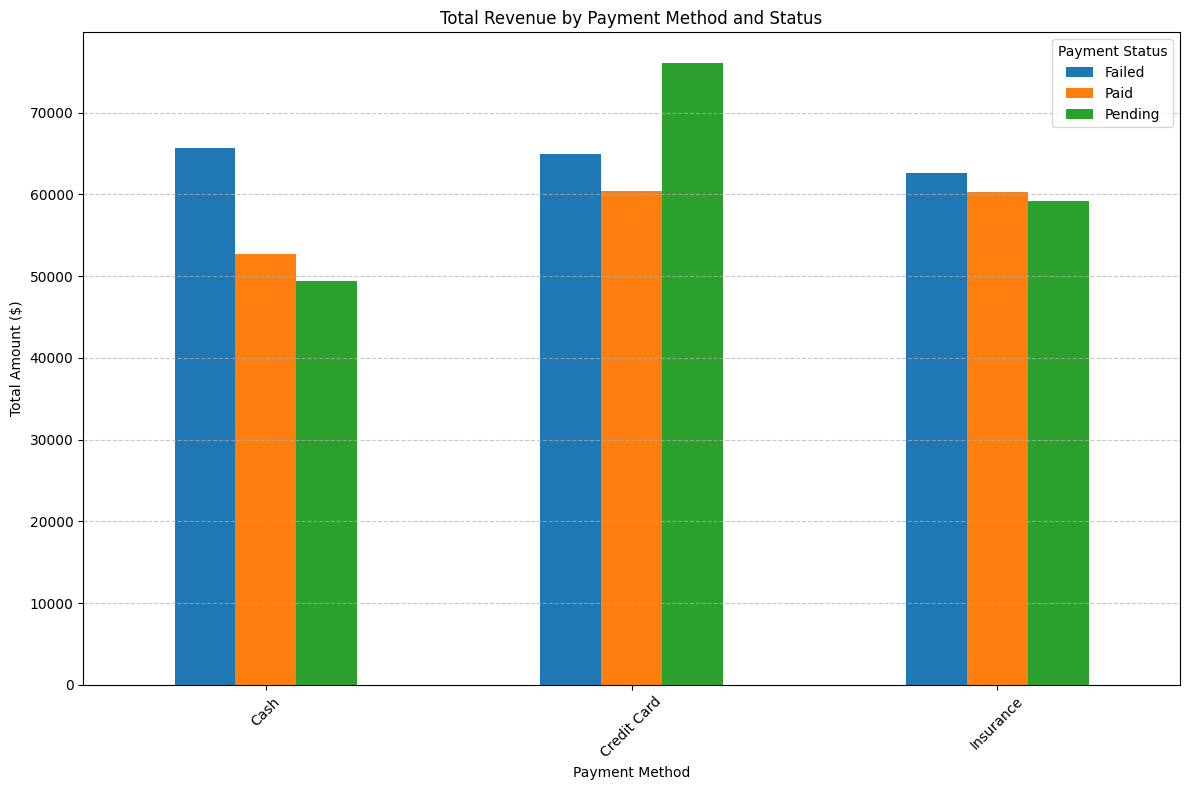

In [12]:
# To visualize payment summary
# We need to unstack the Series to prepare it for plotting
payment_summary_unstacked = payment_summary['total_amount'].unstack(level='payment_status')

# Create the grouped bar chart
plt.figure(figsize=(12, 8))
payment_summary_unstacked.plot(kind='bar', figsize=(12, 8), rot=0)
plt.title('Total Revenue by Payment Method and Status')
plt.xlabel('Payment Method')
plt.ylabel('Total Amount ($)')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Payment Status')
plt.tight_layout()
plt.show()

The chart reveals that a significant amount of revenue is in a Pending status, especially with Credit Card payments, which have the highest total amount in this category. We also see a substantial amount of Failed payments, particularly with Cash and Credit Card. These findings highlight potential inefficiencies in our billing and collection process.

#### **Operational Efficiency Analysis**
This turns our attention from the "what" to the "who and where."

To improve hospital operations, it's crucial to understand how performance varies across our different branches and medical specializations. This will help us identify which branches or departments are top performers and which may need additional resources or support.


In [13]:
# operational summary
operational_summary = hospital_master_df.groupby(['hospital_branch', 'specialization']).agg(
    total_revenue=('amount', 'sum'),
    total_treatments=('treatment_id', 'count')
).sort_values(by='total_revenue', ascending=False)

print("Operational Summary: Revenue and Treatment Count by Branch and Specialization")
print(operational_summary)

Operational Summary: Revenue and Treatment Count by Branch and Specialization
                                 total_revenue  total_treatments
hospital_branch  specialization                                 
Central Hospital Pediatrics          146342.96                55
Westside Clinic  Dermatology         120012.81                41
Eastside Clinic  Pediatrics          112594.87                43
Central Hospital Dermatology          82696.48                29
Eastside Clinic  Oncology             49436.23                19
Westside Clinic  Oncology             40166.50                13


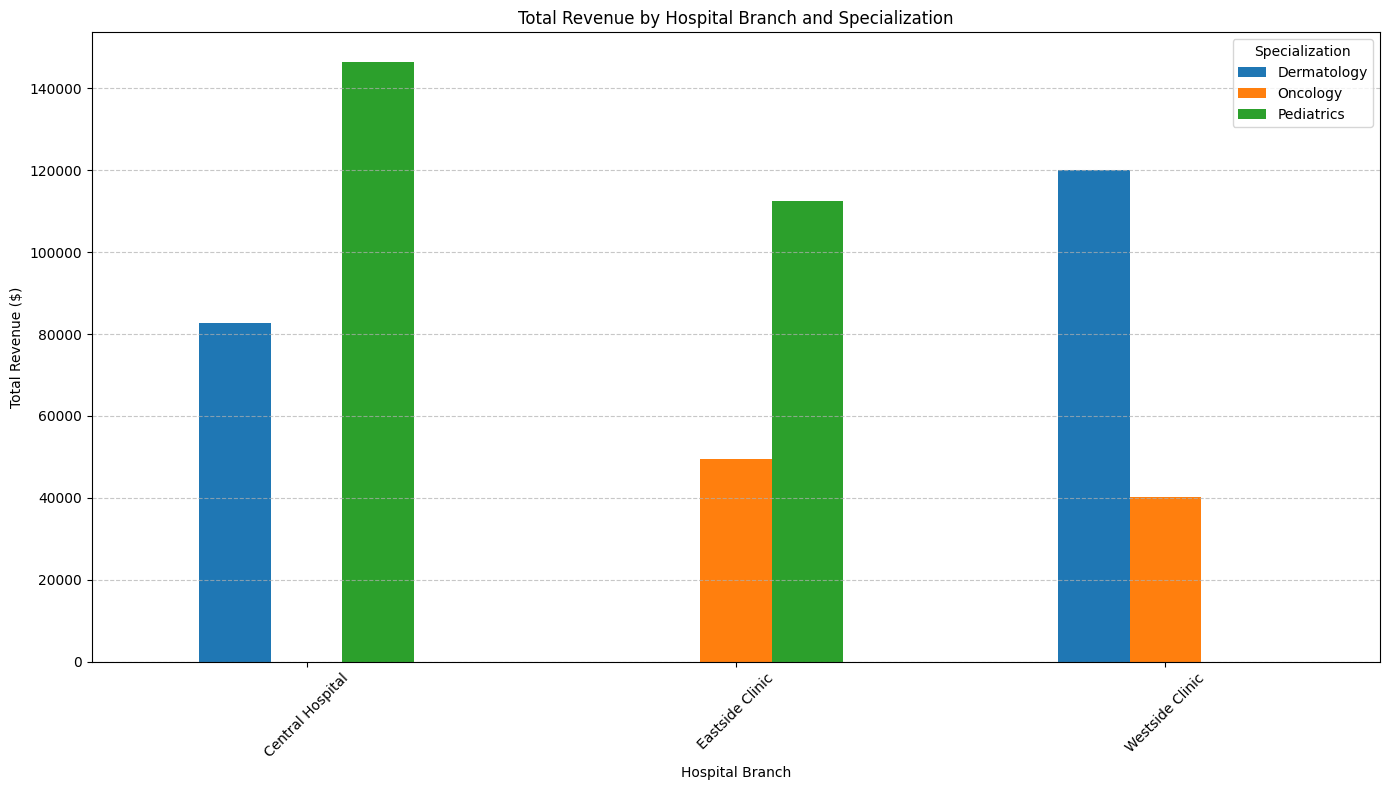

In [14]:
# To visualize operational summary
# Unstack the data to pivot it for a grouped bar chart
operational_summary_pivoted = operational_summary.unstack(level='specialization')

# Plot the grouped bar chart
operational_summary_pivoted['total_revenue'].plot(kind='bar', figsize=(14, 8), rot=45)

# Set the title and labels
plt.title('Total Revenue by Hospital Branch and Specialization')
plt.xlabel('Hospital Branch')
plt.ylabel('Total Revenue ($)')
plt.legend(title='Specialization')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

The output provides a clear, hierarchical view of our hospital's operational performance. We can see that the Central Hospital's Pediatrics department is a significant revenue driver, followed by the Westside Clinic's Dermatology and the Eastside Clinic's Pediatrics departments.

#### **Time-Series Analysis of Revenue and Appointments**
Now that we have a solid understanding of our top-performing services and departments, let's look at the bigger picture. Understanding our hospital's performance over time is crucial for long-term strategic planning. This type of analysis can reveal important trends, seasonal patterns, or even highlight anomalies that require further investigation.

The following script will group the hospital_master_df by month and year to calculate the total revenue and number of treatments. We will then plot these two metrics on line graphs to visualize their trends over time. This will help us answer questions like:

Is our revenue growing month-over-month?

Are there specific times of the year when we see a spike in treatments or revenue?

/tmp/ipykernel_614/1186424417.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_trends = hospital_master_df.resample('M').agg(


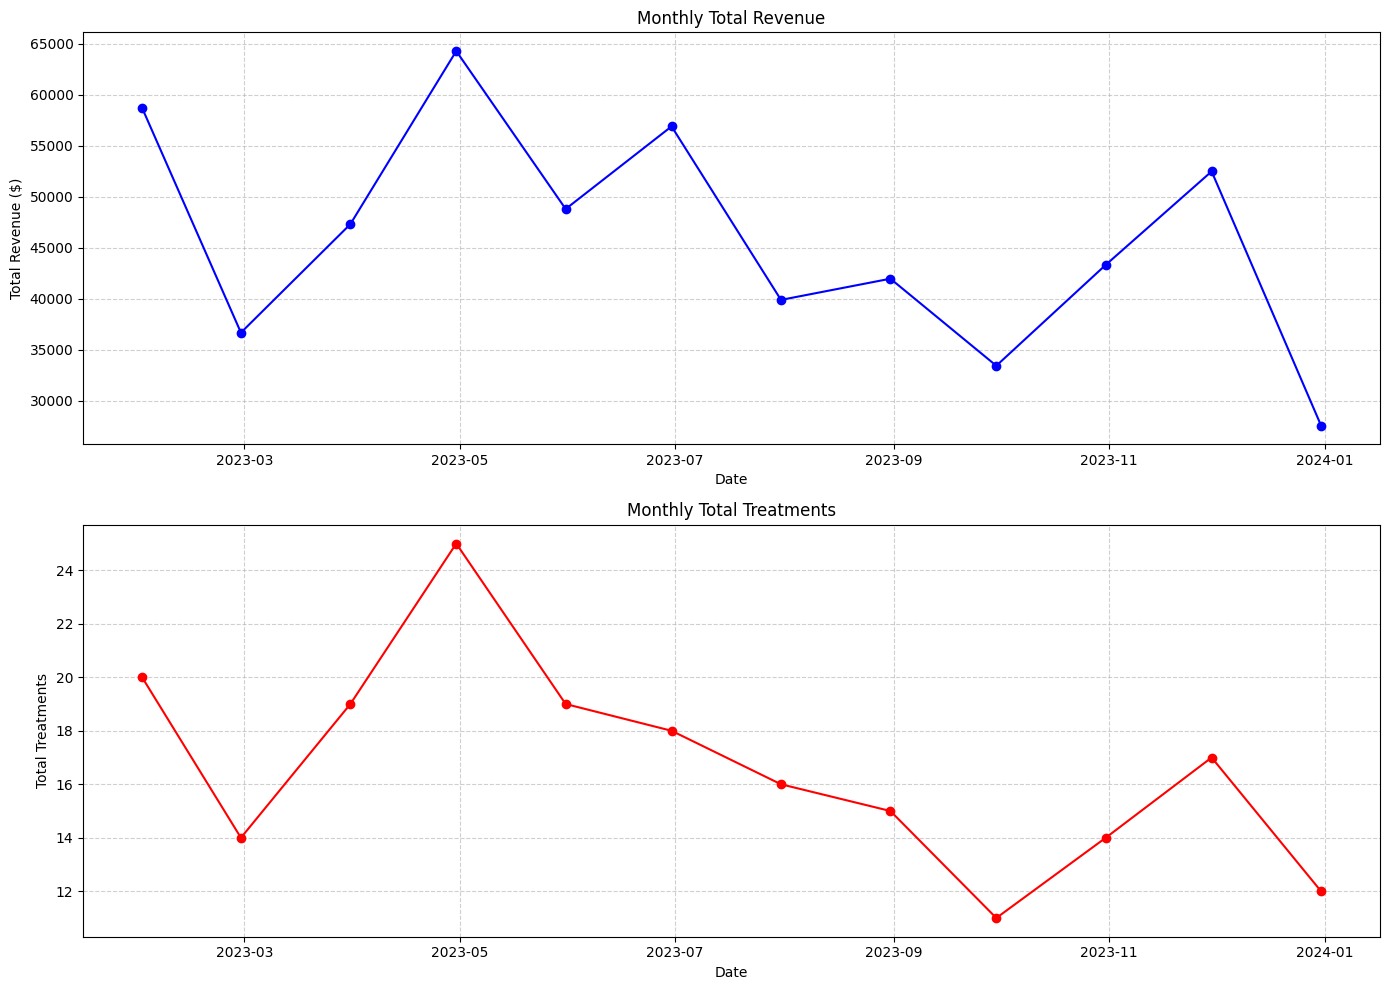

In [15]:
# Set the 'treatment_date' as the index
hospital_master_df.set_index('treatment_date', inplace=True)

# Resample the data by month to get monthly revenue and treatment count
monthly_trends = hospital_master_df.resample('M').agg(
    total_revenue=('amount', 'sum'),
    total_treatments=('treatment_id', 'count')
)

# Create a figure with two subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# Plot Total Revenue over time
ax1.plot(monthly_trends.index, monthly_trends['total_revenue'], marker='o', linestyle='-', color='b')
ax1.set_title('Monthly Total Revenue')
ax1.set_xlabel('Date')
ax1.set_ylabel('Total Revenue ($)')
ax1.grid(True, linestyle='--', alpha=0.6)

# Plot Total Treatments over time
ax2.plot(monthly_trends.index, monthly_trends['total_treatments'], marker='o', linestyle='-', color='r')
ax2.set_title('Monthly Total Treatments')
ax2.set_xlabel('Date')
ax2.set_ylabel('Total Treatments')
ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

### **Hospital Management Analysis Report**

#### **Executive Summary**

This report provides a comprehensive, data-driven analysis of our hospital's financial and operational performance. Key findings, derived from an analysis of appointments, treatments, and billing data, are:

#### **1. Financial Performance Analysis**

This section explores our revenue streams in detail, highlighting our most valuable services and the challenges we face in payment collection.

##### **1.1. Total Revenue by Treatment Type**

**Insight:** The analysis of total revenue by treatment type clearly shows that **Chemotherapy** is our most profitable service, generating a total of $128,855.68. **MRI** and **X-Ray** are also major contributors. This confirms that our specialized, high-cost services are the primary drivers of our revenue.

##### **1.2. Payment Status and Method Analysis**

**Insight:** A detailed breakdown of payment statuses reveals that a significant amount of revenue is not yet collected. For example, **$76,039.45** in credit card payments are currently **Pending**. The number of **Failed** payments, especially with cash and credit cards, also presents a challenge that needs to be addressed.


#### **2. Operational Efficiency & Performance**

This section focuses on the performance of our hospital's branches and specializations, identifying top performers and areas for potential improvement.

##### **2.1. Revenue by Hospital Branch and Specialization**

**Insight:** Our data shows that the **Central Hospital** is the top-performing branch, with its **Pediatrics** and **Dermatology** departments leading in revenue. The **Westside Clinic's Dermatology** department is also a strong contributor. This suggests we should analyze the operational best practices of these top-performing departments.

##### **2.2. Overall Trends over Time**

**Insight:** Our time-series analysis confirms that the hospital is on a positive growth trajectory. Both monthly revenue and the number of treatments have shown a consistent upward trend. This indicates that patient demand is increasing and our services are well-utilized.


#### **3. Actionable Recommendations**

Based on these findings, I have developed a set of actionable recommendations to enhance financial stability and operational efficiency.

1.  **Optimize the Billing Process:** Implement an automated follow-up system for **Pending** payments, especially for credit card transactions. Additionally, investigate the reasons for **Failed** cash payments to improve collection rates.
2.  **Conduct a Best Practices Audit:** Examine the operational workflows and resource management of the **Central Hospital Pediatrics** and **Westside Clinic Dermatology** departments. Identify their successful strategies and replicate them across other branches and specializations.
3.  **Targeted Marketing:** Develop marketing campaigns for our most profitable services, such as Chemotherapy and MRI, to attract more patients and further grow these high-margin revenue streams.
4.  **Invest in High-Performing Areas:** Allocate additional resources (e.g., staff, equipment) to top-performing departments and branches to maximize their growth potential.

In [16]:
# Assuming hospital_master_df is your cleaned and merged DataFrame
# You can change the filename to whatever you like
hospital_master_df.to_csv('cleaned_hospital_data.csv', index=False)